# Preparation for Lab 2 from Group 1 (Wörner, Velez, Northe)

The source code and the binaries from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab2_Spectrum_Analysis).

In [781]:
import numpy as np
from numpy.typing import NDArray
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from collections import defaultdict
import re

In [782]:
lin2db = lambda g: 10 * np.log10(g)

assert 20 == lin2db(100)

In [783]:
bw_fm = lambda beta, BW: 2 * BW * (beta + 1)

assert 2e6 == bw_fm(1, 500e3)

In [784]:
def plot_spectrum(freq: NDArray, amplitude: NDArray,
                          title: str = "Frequency Spectrum",
                          markers: list[dict] = None,
                          db_scale: bool = False,
                          xlim: tuple = None,
                          freq_unit: str = "MHz",
                          freq_scale: float = 1e6):
    """
    Plot frequency spectrum with optional markers and scaling.
    
    Parameters:
    -----------
    freq : NDArray
        Frequency array (in Hz)
    amplitude : NDArray
        Amplitude array
    title : str
        Plot title
    markers : list[dict]
        List of marker dictionaries with keys: 'position', 'name', 'color'
    db_scale : bool
        If True, convert amplitude to dB scale
    xlim : tuple
        Frequency limits for x-axis (in Hz)
    freq_unit : str
        Unit label for frequency axis
    freq_scale : float
        Scaling factor for frequency axis (e.g., 1e6 for MHz)
    """
    
    plot_amplitude = lin2db(amplitude) if db_scale else amplitude
    
    plt.figure(figsize=(12, 5))
    plt.plot(freq / freq_scale, plot_amplitude, label="Spectrum", linewidth=1.5)
    plt.xlabel(f"Frequency ({freq_unit})")
    plt.ylabel("Amplitude [dB]" if db_scale else "Amplitude [lin]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    # Add markers if provided
    if markers:
        for marker in markers:
            # Find closest frequency index
            idx = np.argmin(np.abs(freq - marker['position']))
            plt.plot(freq[idx] / freq_scale, plot_amplitude[idx], 'o', 
                    color=marker['color'], 
                    markersize=8, 
                    markeredgecolor='black', 
                    markeredgewidth=1,
                    label=marker['name'])
    
    # Set x-axis limits if provided
    if xlim:
        plt.xlim(xlim[0] / freq_scale, xlim[1] / freq_scale)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

In [785]:
def plot_time_domain(time: NDArray, 
                    signals: list[dict],
                    time_unit: str = "μs",
                    time_scale: float = 1e6,
                    title: str = "Time Domain Signals"):
    """
    Plot multiple time domain signals in subplots.
    
    Parameters:
    -----------
    time : NDArray
        Time array (in seconds)
    signals : list[dict]
        List of signal dictionaries with keys: 'data', 'label', 'color', 'title'
    time_unit : str
        Unit label for time axis
    time_scale : float
        Scaling factor for time axis (e.g., 1e6 for μs)
    title : str
        Overall title for the figure
    """
    
    n_signals = len(signals)
    
    plt.figure(figsize=(12, 6))
    
    for i, signal in enumerate(signals):
        plt.subplot(n_signals, 1, i + 1)
        plt.plot(time * time_scale, signal['data'], 
                label=signal['label'], 
                color=signal.get('color', 'blue'))
        plt.xlabel(f"Time ({time_unit})")
        plt.ylabel("Amplitude")
        plt.title(signal.get('title', f"Signal {i+1}"))
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

In [786]:
def analyze_mixer_output(f_lo, f_rf, max_order=3):
    components = {
        'dc': [],
        'fundamental': [],
        'harmonics': [],
        'sum_diff': [],
        'intermodulation': []
    }
    
    all_freqs = set()
    
    for n in range(1, max_order + 1):
        for m in range(n + 1):  
            k = n - m  
            
            for sign in [1, -1]:
                freq = m * f_lo + sign * k * f_rf
                freq_original = freq
                freq = abs(freq)
                
                if m == 0 and k == 0:
                    continue

                # Generate LaTeX label parts
                lo = f"f_{{\\mathrm{{LO}}}}" if m == 1 else f"{m}f_{{\\mathrm{{LO}}}}" if m > 1 else ""
                rf = f"f_{{\\mathrm{{RF}}}}" if k == 1 else f"{k}f_{{\\mathrm{{RF}}}}" if k > 1 else ""

                if m == 0:
                    label = f"${rf}$" if sign == 1 else f"$-{rf}$"
                elif k == 0:
                    label = f"${lo}$"
                else:
                    if sign == 1:
                        label = f"${lo} + {rf}$"
                    else:
                        label = f"${lo} - {rf}$"

                if freq_original < 0:
                    if m == 0:
                        label = f"${rf}$"
                    elif k == 0:
                        label = f"${lo}$"
                    else:
                        label = f"${rf} - {lo}$"

                if freq == 0:
                    components['dc'].append({
                        'freq': freq,
                        'terms': f"{m}*f_LO + {sign}*{k}*f_RF",
                        'label': "DC",
                        'order': n
                    })
                elif freq in [f_lo, f_rf]:
                    components['fundamental'].append({
                        'freq': freq,
                        'terms': f"{m}*f_LO + {sign}*{k}*f_RF",
                        'label': label,
                        'order': n
                    })
                elif (m == 0 and k > 1) or (k == 0 and m > 1):
                    components['harmonics'].append({
                        'freq': freq,
                        'terms': f"{m}*f_LO + {sign}*{k}*f_RF",
                        'label': label,
                        'order': n
                    })
                elif n == 2 and m == 1 and k == 1:
                    components['sum_diff'].append({
                        'freq': freq,
                        'terms': f"{m}*f_LO + {sign}*{k}*f_RF",
                        'label': label,
                        'order': n
                    })
                else:
                    components['intermodulation'].append({
                        'freq': freq,
                        'terms': f"{m}*f_LO + {sign}*{k}*f_RF",
                        'label': label,
                        'order': n
                    })

                all_freqs.add(freq)

    # Deduplicate within each category
    for category in components:
        seen_freqs = set()
        unique_components = []
        for comp in components[category]:
            if comp['freq'] not in seen_freqs:
                seen_freqs.add(comp['freq'])
                unique_components.append(comp)
        components[category] = unique_components

    return components




In [787]:
def plot_mixer_spectrum(f_lo, f_rf, max_order=3):
    components = analyze_mixer_output(f_lo, f_rf, max_order)
    
    # Define colors for different component types
    colors = {
        'dc': 'k',
        'fundamental': 'r',
        'harmonics': 'b',
        'sum_diff': 'g',
        'intermodulation': 'y'
    }
    
    # Create figure
    plt.figure(figsize=(16, 10))
    
    # Collect all frequency components for plotting
    all_components = []
    for category, comps in components.items():
        for comp in comps:
            comp['category'] = category
            all_components.append(comp)
    
    # Sort by frequency
    all_components.sort(key=lambda x: x['freq'])
    
    # Plot stems
    for comp in all_components:
        freq_ghz = comp['freq'] / 1e9
        amplitude = 1.0 / comp['order']  # Amplitude decreases with order
        color = colors[comp['category']]
        
        # Plot stem
        plt.stem([freq_ghz], [amplitude], 
                linefmt=f'{color}-', markerfmt=f'{color}o', 
                basefmt=' ')
        
        # Add label above each stem
        plt.text(freq_ghz, amplitude + 0.05, comp['label'], 
                rotation=45, ha='left', va='bottom', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Create custom legend
    legend_elements = []
    for category, color in colors.items():
        if any(comp['category'] == category for comp in all_components):
            legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, 
                                           label=category.replace('_', ' ').title(),
                                           markerfacecolor=color, markersize=8))
    
    # Formatting
    plt.xlabel('Frequency (GHz)', fontsize=12)
    plt.ylabel('Relative Amplitude', fontsize=12)
    plt.title(f'Mixer Output Spectrum\nLO: {f_lo/1e9:.1f} GHz, RF: {f_rf/1e9:.1f} GHz', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.xlim(0, max(f_lo, f_rf) * 3.5 / 1e9)
    plt.xticks(np.arange(0, max(f_lo, f_rf) * 3.5 / 1e9, 0.5))
    plt.ylim(0, 1.3)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [788]:
def simplify_latex_label(label):
    label = label.strip('$')
    label = re.sub(r'\\mathrm\{([A-Z]+)\}', r'\1', label)
    return label

In [789]:
def print_frequency_components(f_lo, f_rf, max_order=3):
    components = analyze_mixer_output(f_lo, f_rf, max_order)
    
    print(f"Mixer Analysis: LO = {f_lo/1e9:.1f} GHz, RF = {f_rf/1e9:.1f} GHz")
    print("=" * 70)
    
    for category, comps in components.items():
        if comps:
            print(f"\n{category.replace('_', ' ').title()}:")
            print("-" * 70)
            for comp in sorted(comps, key=lambda x: x['freq']):
                simple_label = simplify_latex_label(comp['label'])
                print(f"{comp['freq']/1e9:8.2f} GHz  |  {simple_label:<30} |  Order {comp['order']}")

**Simulation time step frequency** 

In [790]:
f_s = 100e9     # [Hz]

## Task 1: AM-Signal

In [791]:
f_c = 2e9       # [Hz]
f_m = 1e6       # [Hz]

t_max = 3e-6
t = np.arange(0, t_max, 1/f_s)
m = 2.1 * np.cos(2 * np.pi * f_m * t) + 3

In [792]:
s_c = np.cos(2 * np.pi * f_c * t)
s_bp = np.multiply(m, s_c)

### Show both the modulating signal and the modulated signal in your time domain plot.

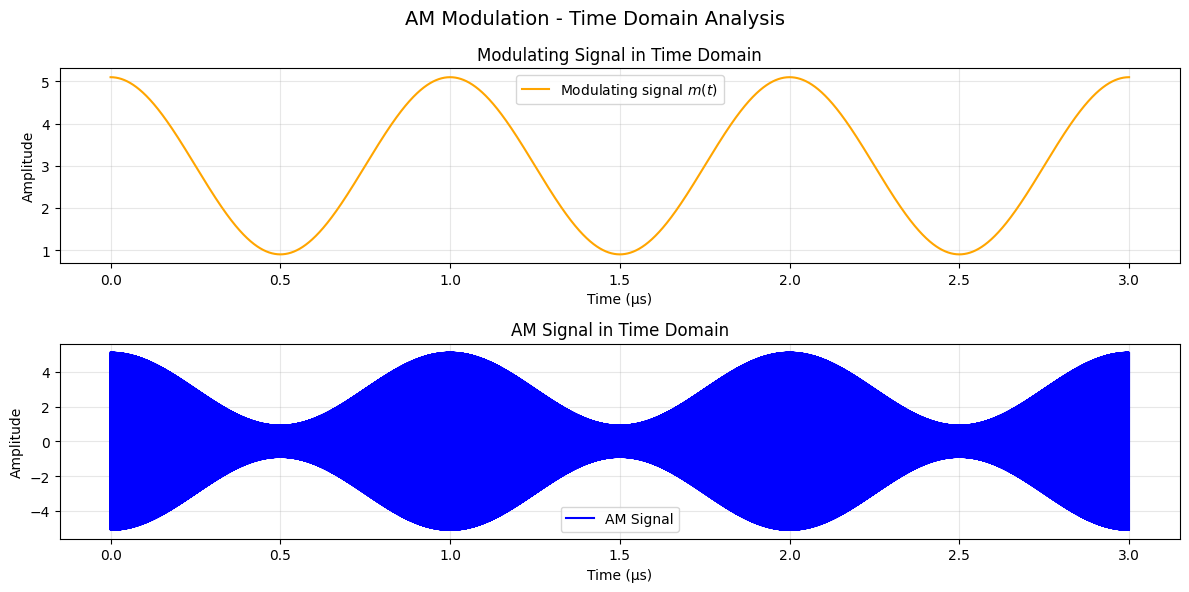

In [793]:
signals = [ {
            'data': m,
            'label': 'Modulating signal $m(t)$',
            'color': 'orange',
            'title': 'Modulating Signal in Time Domain'
        },
        {
            'data': s_bp,
            'label': 'AM Signal',
            'color': 'blue',
            'title': 'AM Signal in Time Domain'
        }
    ]
plot_time_domain(t, signals, title="AM Modulation - Time Domain Analysis")


### Indicate the frequencies and amplitude of the carrier and sidelobes on your spectrum plot.

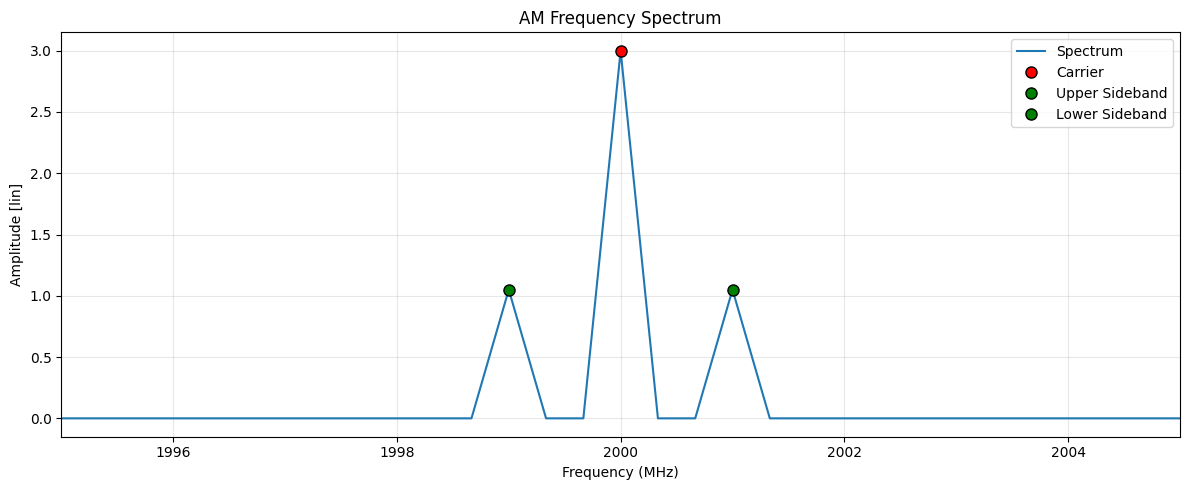

In [794]:
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies + normalize
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])


markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]
plot_spectrum(f_pos, S_pos, title="AM Frequency Spectrum", markers=markers, xlim=(f_c-5e6, f_c+5e6))

### What is the modulation index? Show all necessary calculations.

In [795]:
A_m = 2.1
A_c = 3
mu = A_m / A_c
print(f"Modulation index (μ): {mu:.2f}")

Modulation index (μ): 0.70


### What are the frequencies of the upper and lower sidebands?

We expect the frequency of the sideband at 
$$f_{SB} = f_c \pm f_m$$

In [796]:
carrier_idx = np.argmin(np.abs(f_pos - f_c))
usb_idx = np.argmin(np.abs(f_pos - (f_c + f_m)))
lsb_idx = np.argmin(np.abs(f_pos - (f_c - f_m)))

carrier_freq = f_pos[carrier_idx]
usb_freq = f_pos[usb_idx]
lsb_freq = f_pos[lsb_idx]

print(f"Expected Carrier: {f_c/1e6:.2f} MHz, FFT Peak at: {carrier_freq/1e6:.2f} MHz")
print(f"Expected USB: {f_c/1e6 + f_m/1e6:.2f} MHz, FFT Peak at: {usb_freq/1e6:.2f} MHz")
print(f"Expected LSB: {f_c/1e6 - f_m/1e6:.2f} MHz, FFT Peak at: {lsb_freq/1e6:.2f} MHz")


Expected Carrier: 2000.00 MHz, FFT Peak at: 2000.00 MHz
Expected USB: 2001.00 MHz, FFT Peak at: 2001.00 MHz
Expected LSB: 1999.00 MHz, FFT Peak at: 1999.00 MHz


### What is the difference in amplitude (in dB) between the carrier and sidebands? Show all necessary calculations

In [797]:
carrier_amp = S_pos[carrier_idx]
sideband_amp = S_pos[usb_idx]

diff_dB = 20 * np.log10(carrier_amp / sideband_amp)
print(f"Carrier vs Sideband amplitude difference: {diff_dB:.2f} dB")

Carrier vs Sideband amplitude difference: 9.12 dB


## Task 2

In [798]:
f_c         = 2e9       # [Hz]
f_m         = 60e6      # [Hz]
mod_index   = 8         # [ ] 

t_max       = 33e-9     # [s]

In [799]:
t = np.arange(0, t_max, 1/f_s)

s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

### Show both the modulating signal and the modulated signal in time domain

Below in the lower plot it is cleary visible how the frequency changes based on the modulated signal from above.

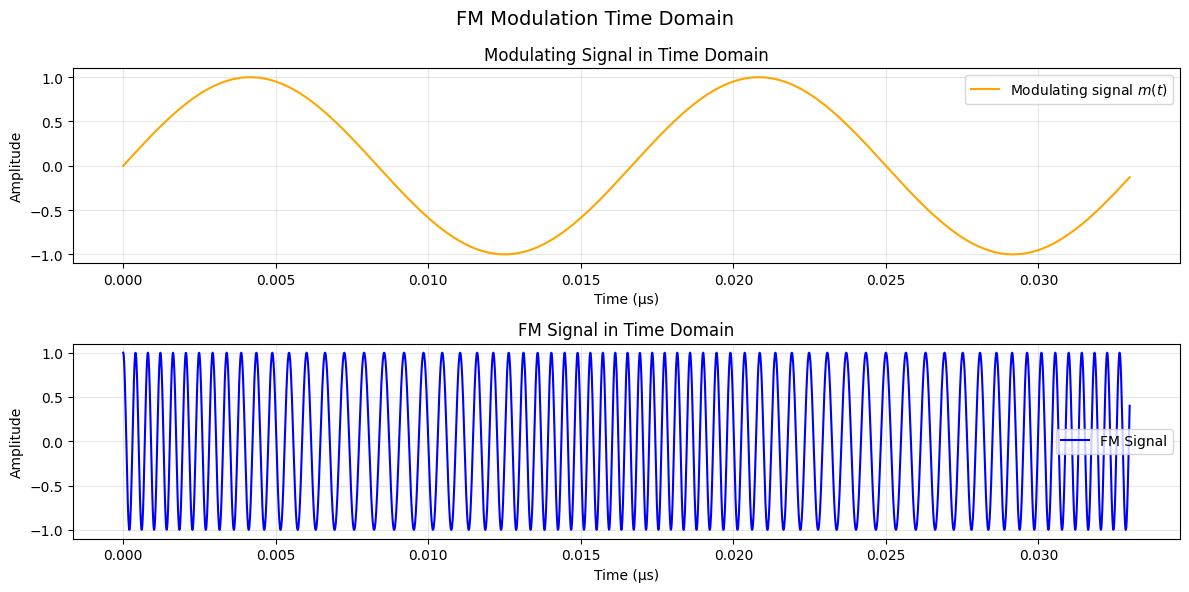

In [800]:
signals = [ {
            'data': s_mod,
            'label': 'Modulating signal $m(t)$',
            'color': 'orange',
            'title': 'Modulating Signal in Time Domain'
        },
        {
            'data': s_bp,
            'label': 'FM Signal',
            'color': 'blue',
            'title': 'FM Signal in Time Domain'
        }
    ]

plot_time_domain(t, signals, title="FM Modulation Time Domain")

In [801]:
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies + Normalize amplitude
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])

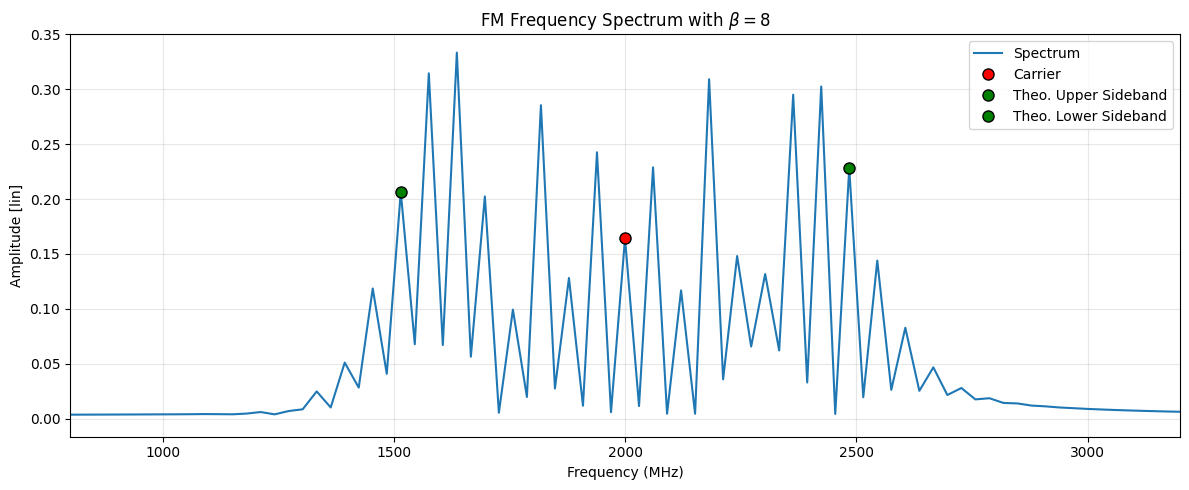

In [802]:
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Theo. Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Theo. Lower Sideband', 'color': 'green'}
    ]

plot_spectrum(f_pos, S_pos, title=r"FM Frequency Spectrum with $\beta = $" + f"{mod_index}", markers=markers, xlim=(f_c - 20 * f_m, f_c + 20 * f_m))

#### 3.2.2 For the same FM signal as in question 1, change 𝛽 to 0.1. Plot the spectrum. Indicate the frequencies and amplitude of the carrier and sidebands on your spectrum plot.

In [803]:
mod_index = 0.1 
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies + normalize amplitude
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])


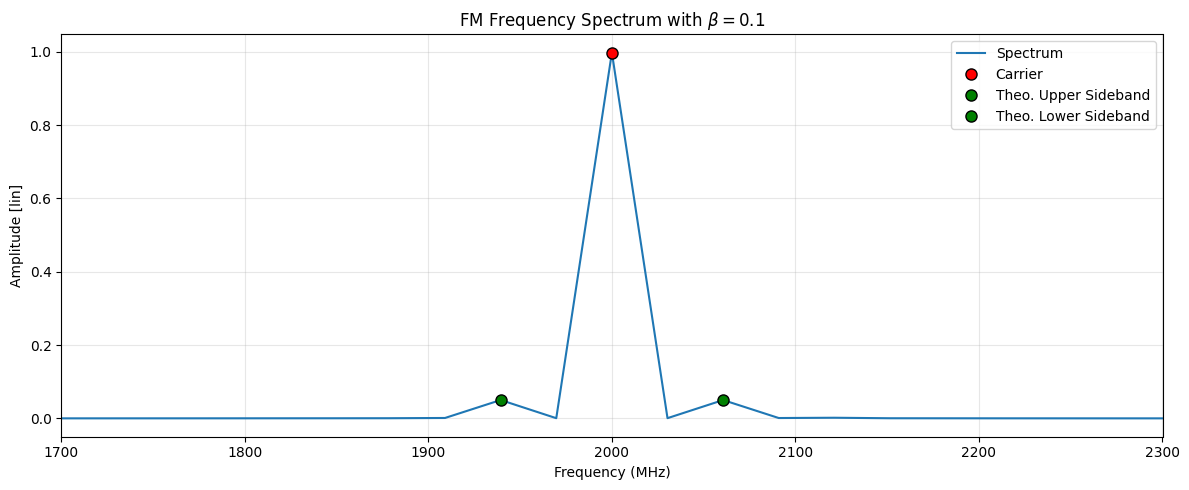

In [804]:
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + (mod_index + 1) * f_m, 'name': 'Theo. Upper Sideband', 'color': 'green'},
        {'position': f_c - (mod_index + 1) * f_m, 'name': 'Theo. Lower Sideband', 'color': 'green'}
    ]

plot_spectrum(f_pos, S_pos, title=r"FM Frequency Spectrum with $\beta = $" + f"{mod_index}", markers=markers, xlim=(f_c - 5 * f_m, f_c + 5 * f_m))

#### For the same FM signal as in question 1, now change 𝛽 to 20. Plot the spectrum

In [805]:
mod_index = 20 
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])


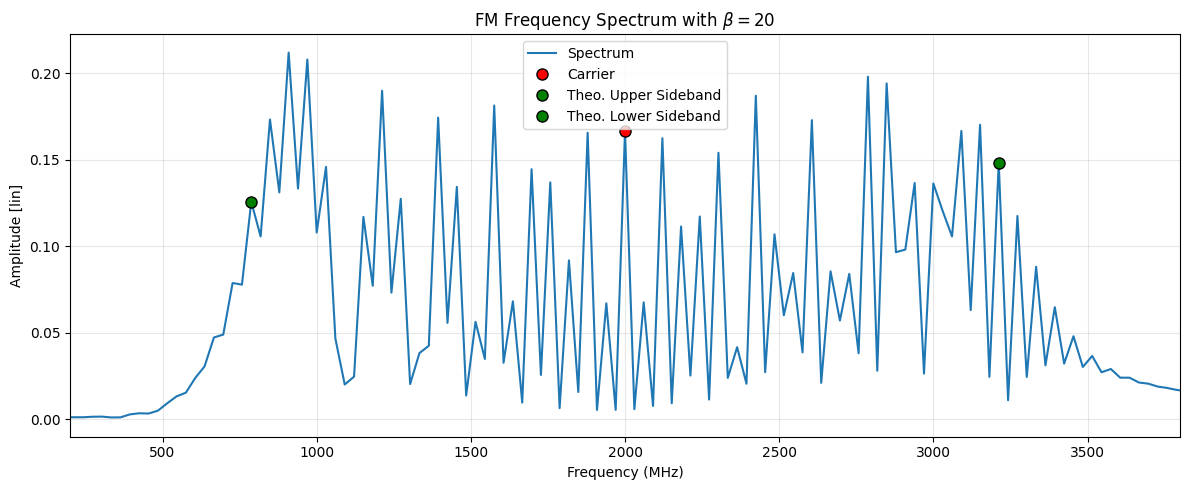

In [806]:
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Theo. Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Theo. Lower Sideband', 'color': 'green'}
    ]

plot_spectrum(f_pos, S_pos, title=r"FM Frequency Spectrum with $\beta = $" + f"{mod_index}", markers=markers, xlim=(f_c - 30 * f_m, f_c + 30 * f_m))

### 3.2.4 Complete the following table

**Calculation of $\Delta f$ and $BW_{theo}$**

For **narrowband angle modulation**:

$$\Delta f \ll B \quad \Rightarrow \quad \beta < 1 \quad \Rightarrow \quad B_{\text{FM}} \approx 2B $$

For **wideband angle modulation**:

$$ 1 \leq \beta < 10 \quad \Rightarrow \quad B_{\text{FM}} = 2B(\beta + 1) $$

For **ultra-wideband angle modulation**:

$$ \Delta f \gg B \quad \Rightarrow \quad \beta \geq 10 \quad \Rightarrow \quad B_{\text{FM}} \approx 2\Delta f $$

In [807]:
b = 0.1
print(f"For FM-Modulation index of ß = {b}")
print(f"Delta f: {(b * f_m)/1e6} MHz")
print(f"Theoretical BW: {((2 * f_m)/1e6):.2f} MHz\n")

b = 8
print(f"For FM-Modulation index of ß = {b}")
print(f"Delta f: {(b * f_m)/1e6} MHz")
print(f"Theoretical BW: {(bw_fm(b, f_m))/1e6} MHz\n")


b = 20
print(f"For FM-Modulation index of ß = {b}")
print(f"Delta f: {(b * f_m)/1e6} MHz")
print(f"Theoretical BW: {(2 * b * f_m)/1e6} MHz\n")

For FM-Modulation index of ß = 0.1
Delta f: 6.0 MHz
Theoretical BW: 120.00 MHz

For FM-Modulation index of ß = 8
Delta f: 480.0 MHz
Theoretical BW: 1080.0 MHz

For FM-Modulation index of ß = 20
Delta f: 1200.0 MHz
Theoretical BW: 2400.0 MHz



| Modulation Index (𝛽) | Type of FM        | Δ𝑓 [MHz] | Theoretical Bandwidth [MHz] | Simulated Bandwidth [MHz] |
|----------------------|-------------------|----------|------------------------------|---------------------------|
| 0.1                  | Narrowband FM     | 6.0      | 120.0                        |   120.0                        |
| 8                    | Wideband FM       | 480.0    | 1080.0                       |   $f_{m,high} \approx 2500$, $f_{m,low}\approx 1500$ $BW_{sim}= 1000$                     |
| 20                   | Ultra-wideband FM | 1200.0   | 2400.0                       | $f_{m,high} \approx 3200$, $f_{m,low}\approx 800$ $BW_{sim}= 2400$ |


#### 3.2.5 For the same FM signal as in question 1, change 𝛽 to 1 and then to 2.4

Simulated BW: 240.00 MHz


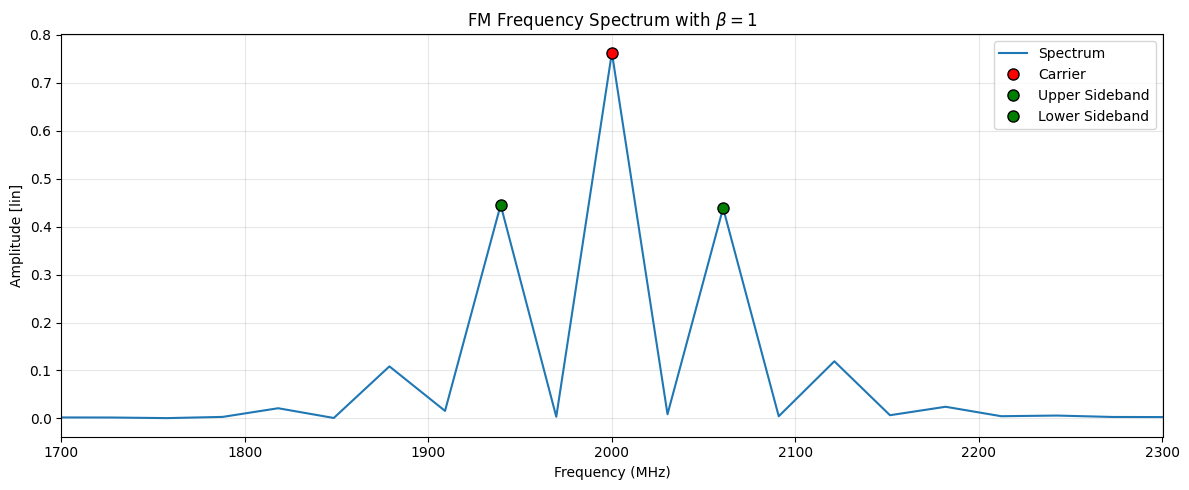

In [808]:
mod_index = 1
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]

print(f"Simulated BW: {((bw_fm(mod_index, f_m))/1e6):.2f} MHz")
plot_spectrum(f_pos, S_pos, title=r"FM Frequency Spectrum with $\beta = $" + f"{mod_index}", markers=markers, xlim=(f_c - 5 * f_m, f_c + 5 * f_m))


Simulated BW: 408.00 MHz


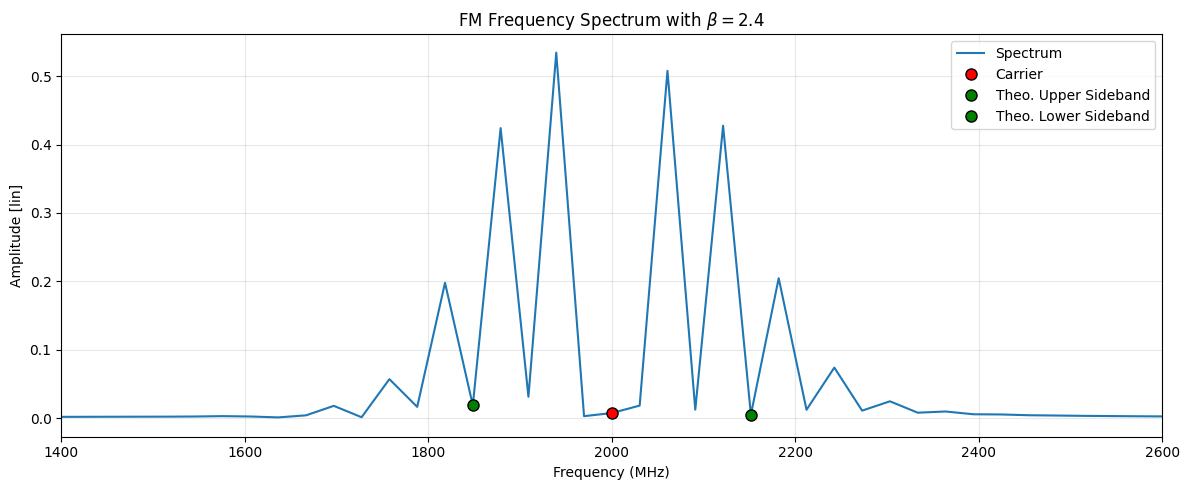

In [809]:
mod_index = 2.4
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Theo. Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Theo. Lower Sideband', 'color': 'green'}
    ]

print(f"Simulated BW: {((bw_fm(mod_index, f_m))/1e6):.2f} MHz")
plot_spectrum(f_pos, S_pos, title=r"FM Frequency Spectrum with $\beta = $" + f"{mod_index}", markers=markers, xlim=(f_c - 600e6, f_c + 600e6))


#### What is the main difference you notice between the two spectra? Why does this happen?

Differences from $\beta = 2.4$ compared to $\beta = 1$:
- Even number of peaks results in no peak at the carrier frequency
- Unsymmetric peak powers
- More peaks -> expected from the higher modulation index

Explanation:
- The reason for the disappeared carrier is that $\beta = 2.4$ is where the Bessel function is $J_0(\beta) = 0$
- The unsymmetric peak powers can be explained be the Bessel function aswell, as the n-th order Besselfunction $J_n$ describes the power of the sideband.

## Task 3

In [810]:
duty_cycle = 0.05   # [ ]
t_s = 1e-9          # [s]

### What is the PRF of the signal? What is 𝜏 (in ns)?

In [811]:
t = np.arange(0, 2*t_s, 1 / f_s)

n_samples_period = int(t_s / (1 / f_s))
n_samples_on = int(n_samples_period * duty_cycle)
signal = np.zeros(shape=(len(t)))
signal[: n_samples_on] = 1
signal[n_samples_period : n_samples_on+n_samples_period] = 1

$$PRF = \frac{1}{PRI} = \frac{1}{T_s}$$
D is used as Duty Cycle:
$$\tau = D \cdot T_s$$

In [812]:
t_on = t_s * duty_cycle
print(f"On time: {t_on} s")
print(f"PRF = {((1 / t_s) / 1e6):.2f} MHz")

On time: 5.000000000000001e-11 s
PRF = 1000.00 MHz


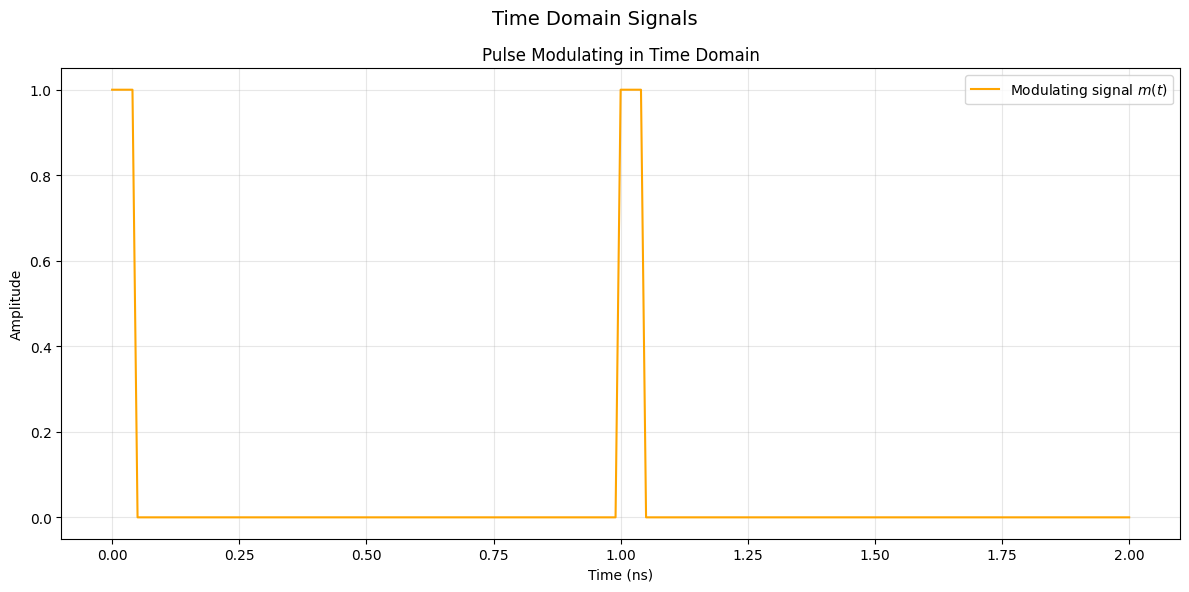

In [813]:
signals_d = [ {
            'data': signal,
            'label': 'Modulating signal $m(t)$',
            'color': 'orange',
            'title': 'Pulse Modulating in Time Domain'
        }]
plot_time_domain(t, signals_d, time_unit="ns", time_scale=1e9)

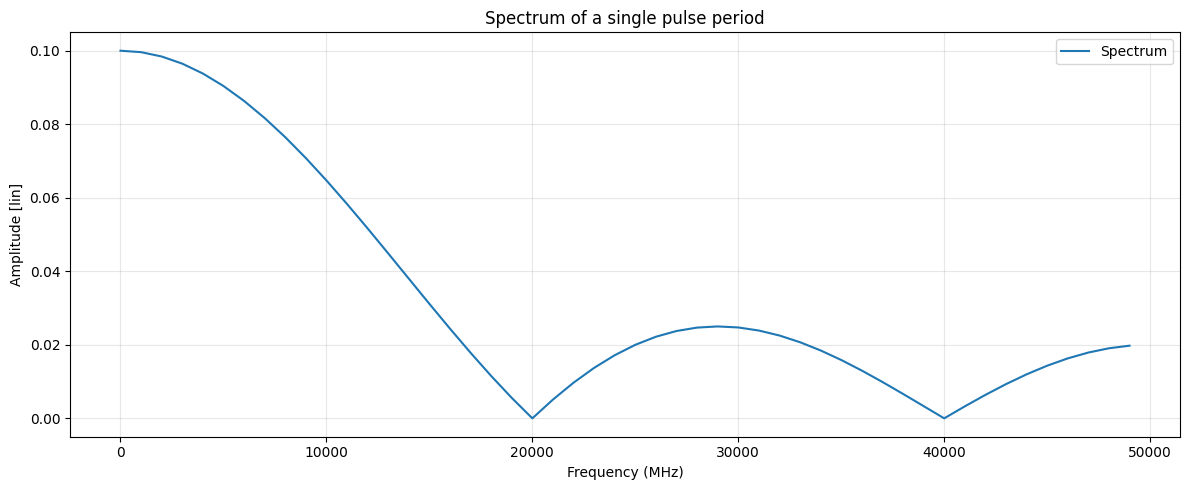

In [814]:
N = len(t[:100])
S = fft(signal[:100])
f = fftfreq(N, 1/f_s)

plot_spectrum(f[:50], 2 / N * np.abs(S[:50]), title=f"Spectrum of a single pulse period")

### What would be an appropriate $RBW$ setting to obtain the line spectrum on the spectrum analyser for this pulse signal? Why?

As stated in the document for obtaining the line spectrum $RBW < \frac{1}{T}$ has to be fulfilled. With that we should be able to resolve the individual frequencies.

In [815]:
max_RBW = 1 / t_s
print(f"Max RBW for line spectrum {(max_RBW/1e6):.2f} MHz")

Max RBW for line spectrum 1000.00 MHz


#### What would be an appropriate RBW setting to obtain the envelope spectrum on the spectrum analyser for this pulse signal? Why?

As stated in the document for obtaining the evelope spectrum $ \frac{1}{T} < RBW < \frac{1}{\tau}$ has to be fulfilled. The spectrum analyzer is now sampling over multiple pulses, therefore we get the spectrum of multiple pulses, which increases also the signal power. But the sampling rate should be equal or higher than the Bandwidth of the individual pulse, or we get the spectrum of the single ideally boxcar-shaped pulse.  

In [816]:
PRF = 1 / t_s
BW_pulse = 1 / (t_s * duty_cycle)
print(f"{(PRF/1e6):.2f} MHz < RBW < {(BW_pulse / 1e6):.2f} MHz")

1000.00 MHz < RBW < 20000.00 MHz


### Task 4

**A sinusoidal LO signal with a frequency of 4 GHz and a sinusoidal RF signal with a frequency
of 1.5 GHz are used as inputs to a mixer. These two signals are fed to a mixer with non-linear
characteristics. Assume the output of the mixer can be described by the power series in Eq. 2-7
(up to 𝑛 = 3). Draw or plot the frequency spectrum of the output of the mixer. Indicate the
fundamental frequencies, the possible harmonics and the sum and difference
frequencies/intermodulation products. Plot the different components in separate colours and
write down their respective frequencies**

In [817]:
f_lo = 4e9      # [Hz]
f_rf = 1.5e9    # [Hz]

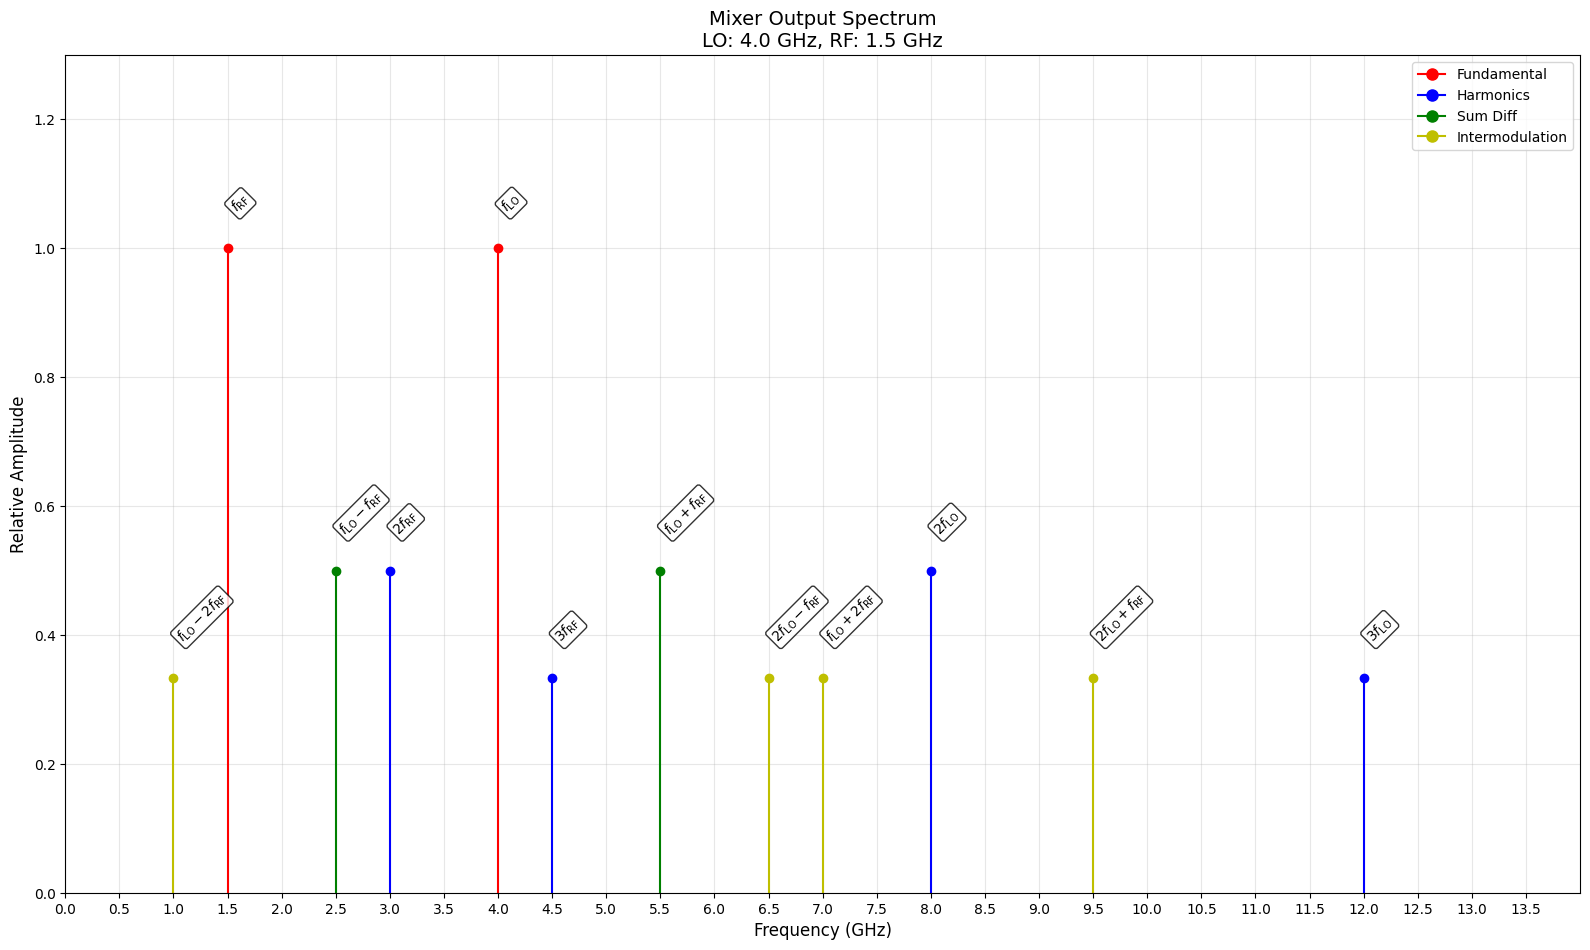

Mixer Analysis: LO = 4.0 GHz, RF = 1.5 GHz

Fundamental:
----------------------------------------------------------------------
    1.50 GHz  |  f_{RF}                         |  Order 1
    4.00 GHz  |  f_{LO}                         |  Order 1

Harmonics:
----------------------------------------------------------------------
    3.00 GHz  |  2f_{RF}                        |  Order 2
    4.50 GHz  |  3f_{RF}                        |  Order 3
    8.00 GHz  |  2f_{LO}                        |  Order 2
   12.00 GHz  |  3f_{LO}                        |  Order 3

Sum Diff:
----------------------------------------------------------------------
    2.50 GHz  |  f_{LO} - f_{RF}                |  Order 2
    5.50 GHz  |  f_{LO} + f_{RF}                |  Order 2

Intermodulation:
----------------------------------------------------------------------
    1.00 GHz  |  f_{LO} - 2f_{RF}               |  Order 3
    6.50 GHz  |  2f_{LO} - f_{RF}               |  Order 3
    7.00 GHz  |  f_{LO} + 2f

In [818]:
plot_mixer_spectrum(f_lo, f_rf)
print_frequency_components(f_lo, f_rf, max_order=3)